# VLM Frame Inspection Walkthrough

Interactively inspect extracted frames, vision-language model (VLM) scores, and the downstream features/labels that feed the demo pipeline. Run the notebook top-to-bottom after configuring paths and ensuring your OpenRouter credentials are available in the environment (.env).

## Prerequisites
- Install dependencies with `pip install -r vlm-demo/requirements.txt`.
- Ensure `OPENROUTER_API_KEY` (and optional `VLM_MODEL_ID`) are set – e.g. load them via the project `.env`.
- Update the configuration cell below if you want to analyse a different video, time window, or price file.

In [12]:
from pathlib import Path
from datetime import datetime
import os
import sys
import pandas as pd
from IPython.display import display, Image

%matplotlib inline
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve()
SRC_DIR = REPO_ROOT / 'vlm-demo' / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))


In [ ]:
# --- Configuration -------------------------------------------------------
VIDEO_PATH = REPO_ROOT  / 'data' / 'videos' / 'DAL.mp4'
FRAMES_DIR = REPO_ROOT / 'data' / 'frames'
BARS_PATH = REPO_ROOT / 'data' / 'prices' / 'DAL_1min.csv'
EVENT_TIME = '2025-10-09T12:00:00Z'  # prefer UTC timestamps
T_START = 0.0
T_END = 210.0
FRAME_STRIDE = 30.0
WINDOW = 60  # seconds per aggregation bin
MIN_CONF = 0.3
HORIZONS = [5, 60]
MAX_SCORING_FRAMES = None  # set to an int to only score the first N frames


Adjust any of the parameters above before continuing. Setting `MAX_SCORING_FRAMES` to a smaller number is handy for quick dry runs while validating the pipeline.

In [19]:
VIDEO_PATH

PosixPath('/home/guest/Desktop/wqmsc/Capstone_project/facial-expression-analysis/vlm-demo/data/videos/DAL.mp4')

In [20]:
from extract_frames import extract_frames

FRAMES_DIR.mkdir(parents=True, exist_ok=True)
frames = extract_frames(str(VIDEO_PATH), str(FRAMES_DIR), T_START, T_END, FRAME_STRIDE)
frames_df = pd.DataFrame(frames)
print(f'Total extracted frames: {len(frames_df)}')
frames_df.head()

Total extracted frames: 8


,frame,ts
0,/home/guest/Desktop/wqmsc/Capstone_project/fac...,0.000000
1,/home/guest/Desktop/wqmsc/Capstone_project/fac...,29.996633
2,/home/guest/Desktop/wqmsc/Capstone_project/fac...,59.993267
3,/home/guest/Desktop/wqmsc/Capstone_project/fac...,89.989900
4,/home/guest/Desktop/wqmsc/Capstone_project/fac...,119.986533


### Preview sampled frames

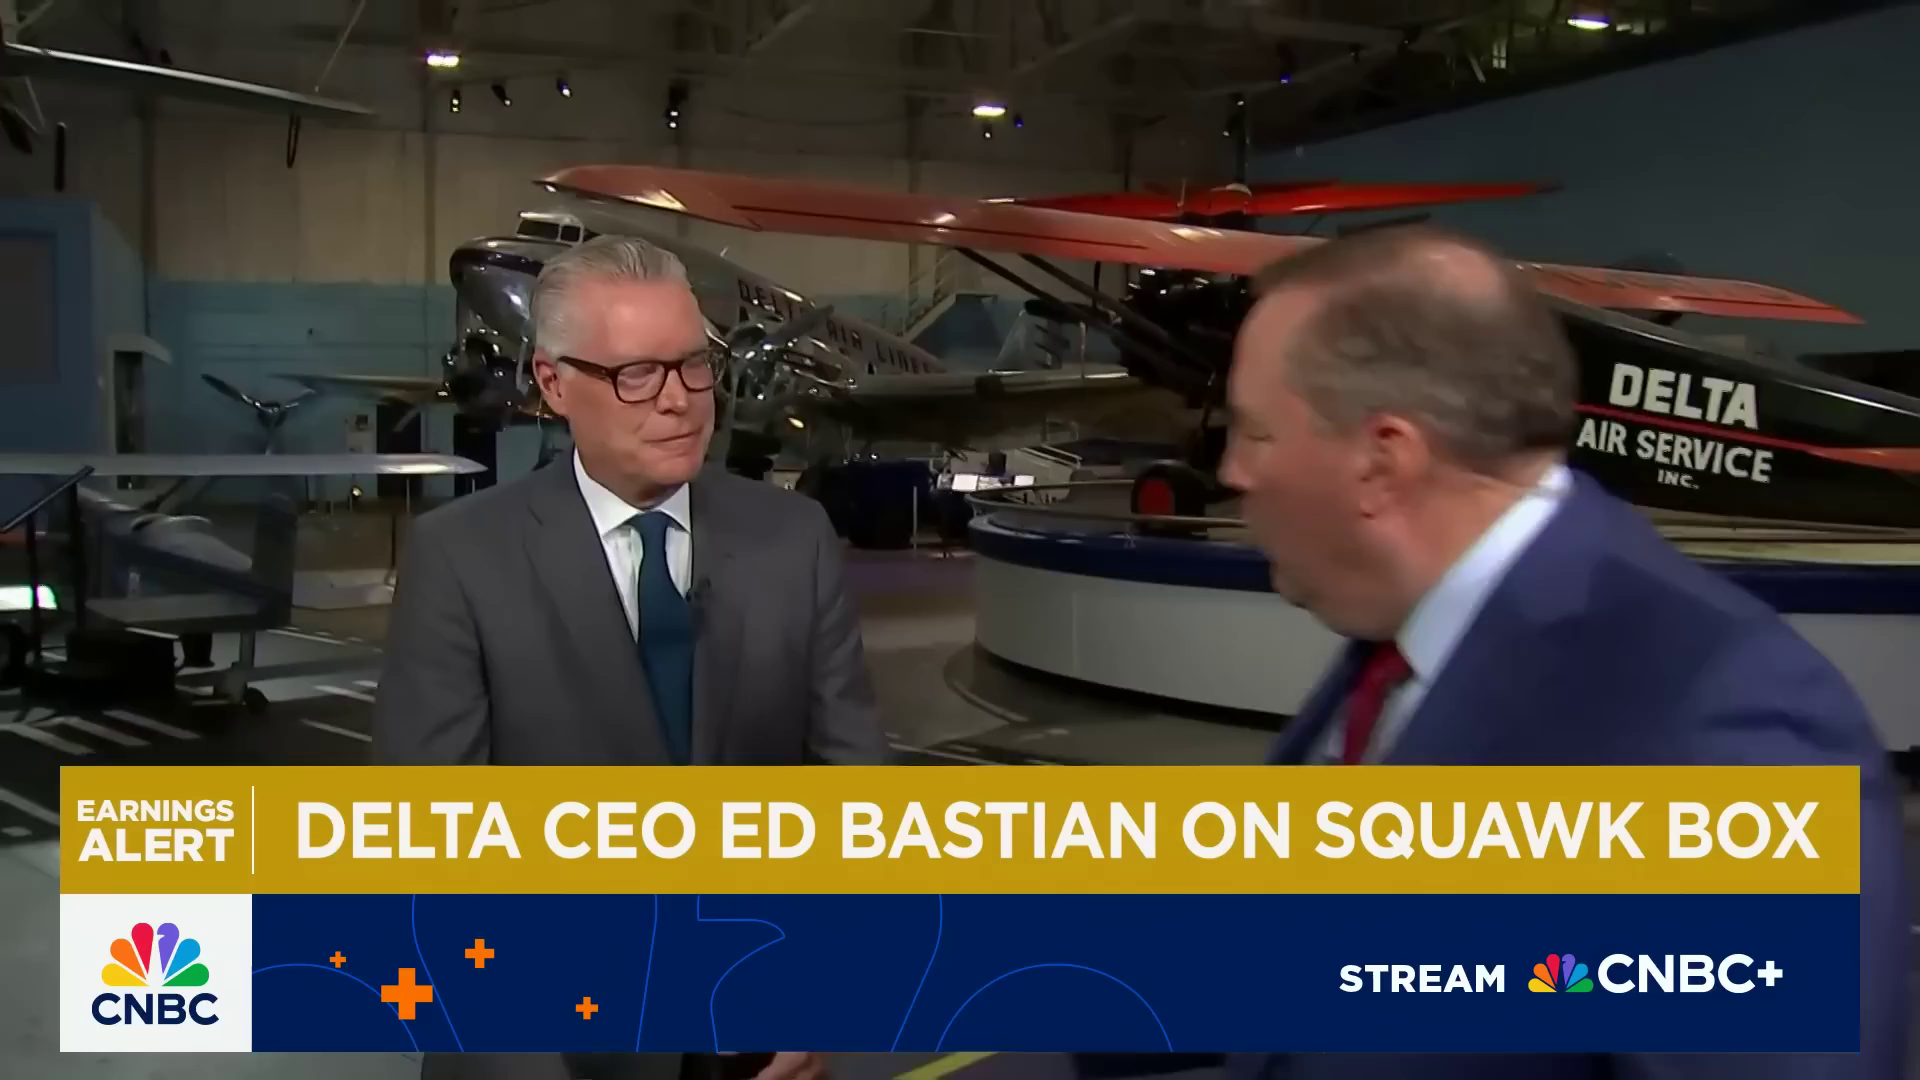

{'ts': 0.0}

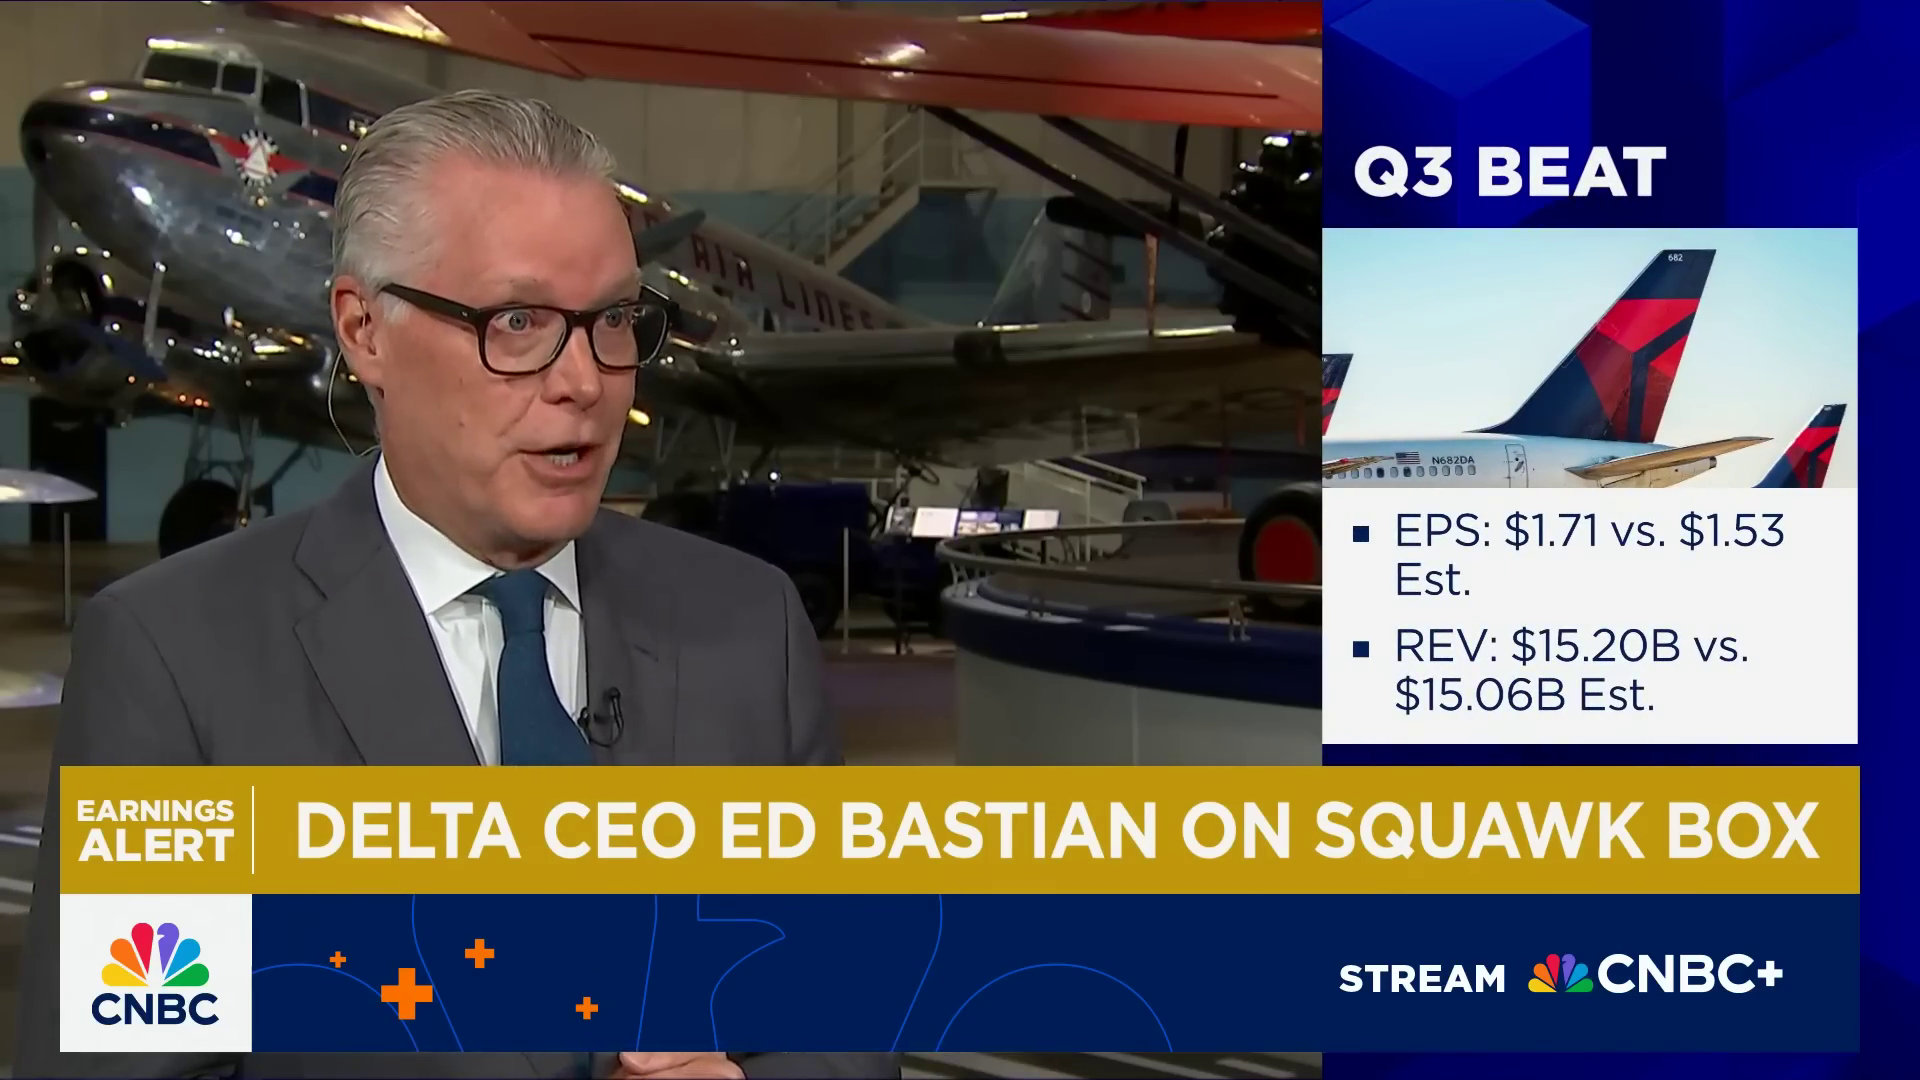

{'ts': 29.996633333333335}

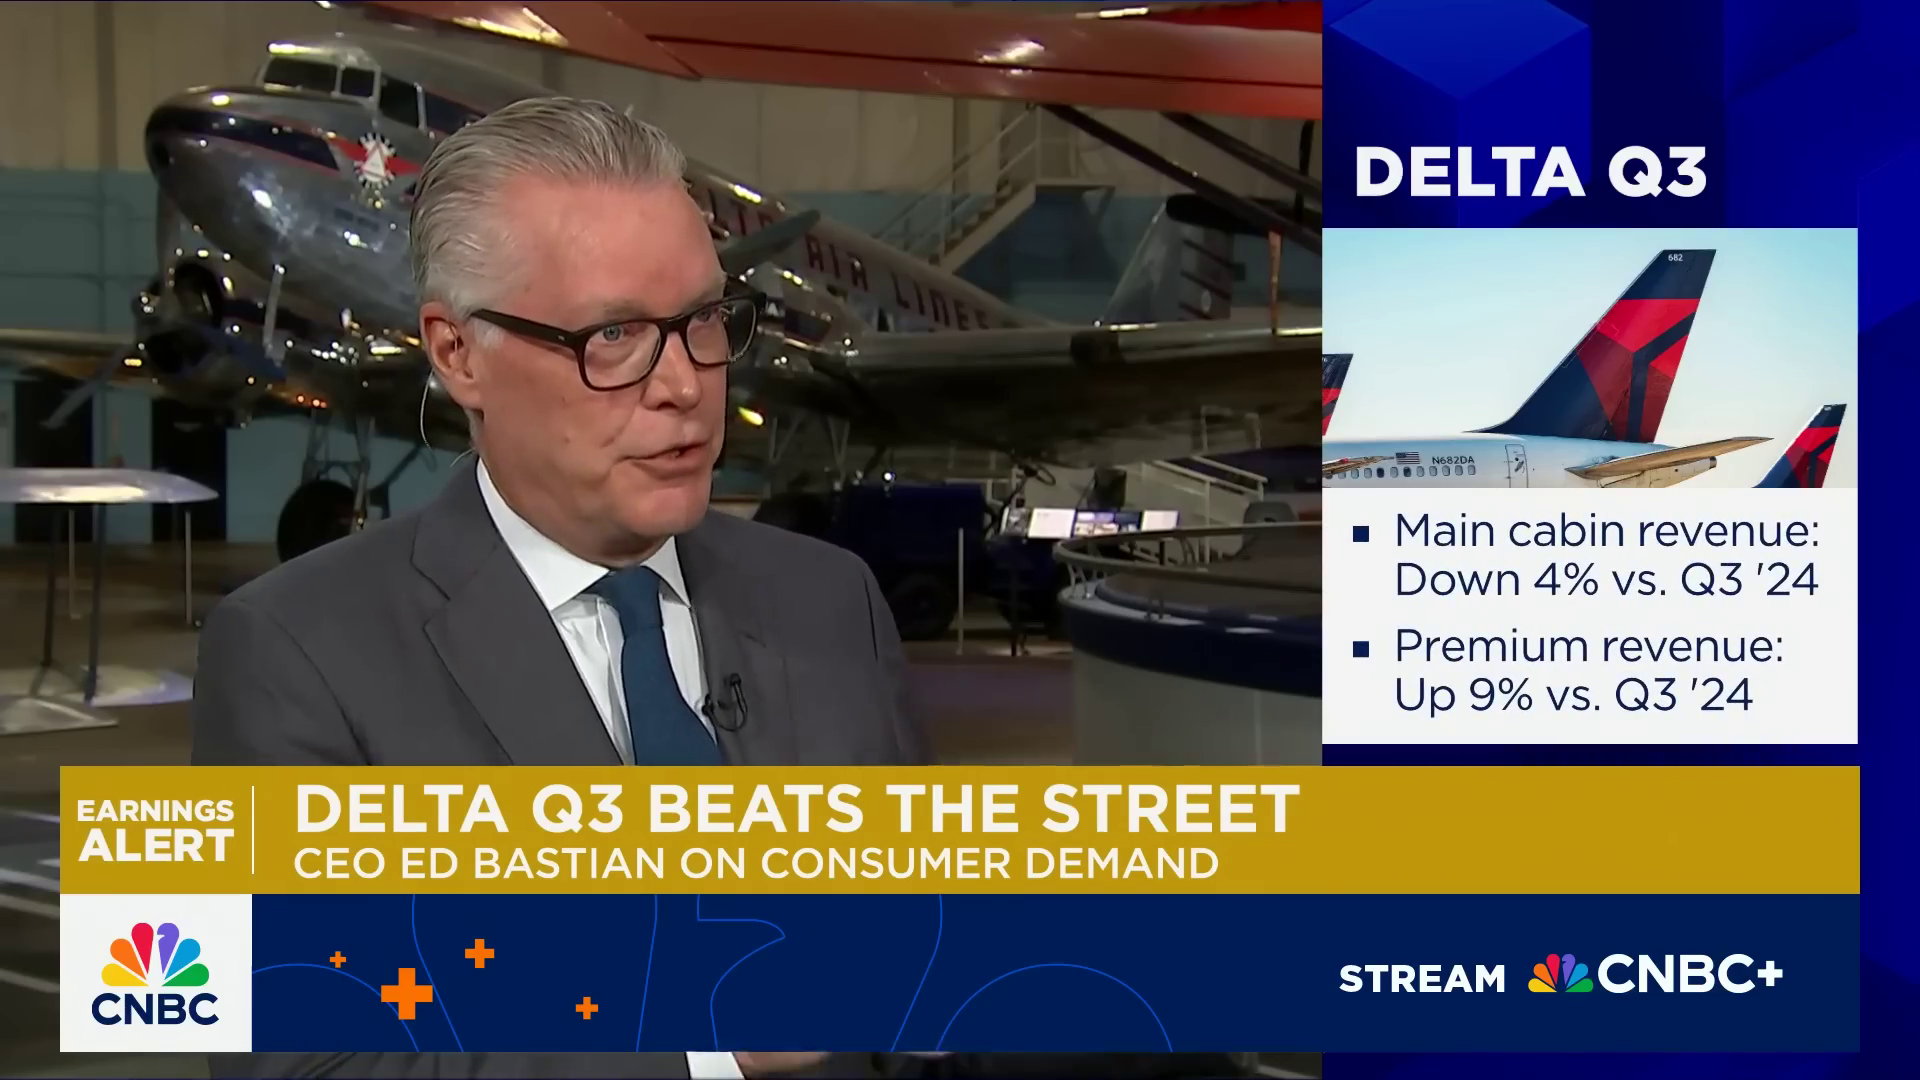

{'ts': 59.99326666666667}

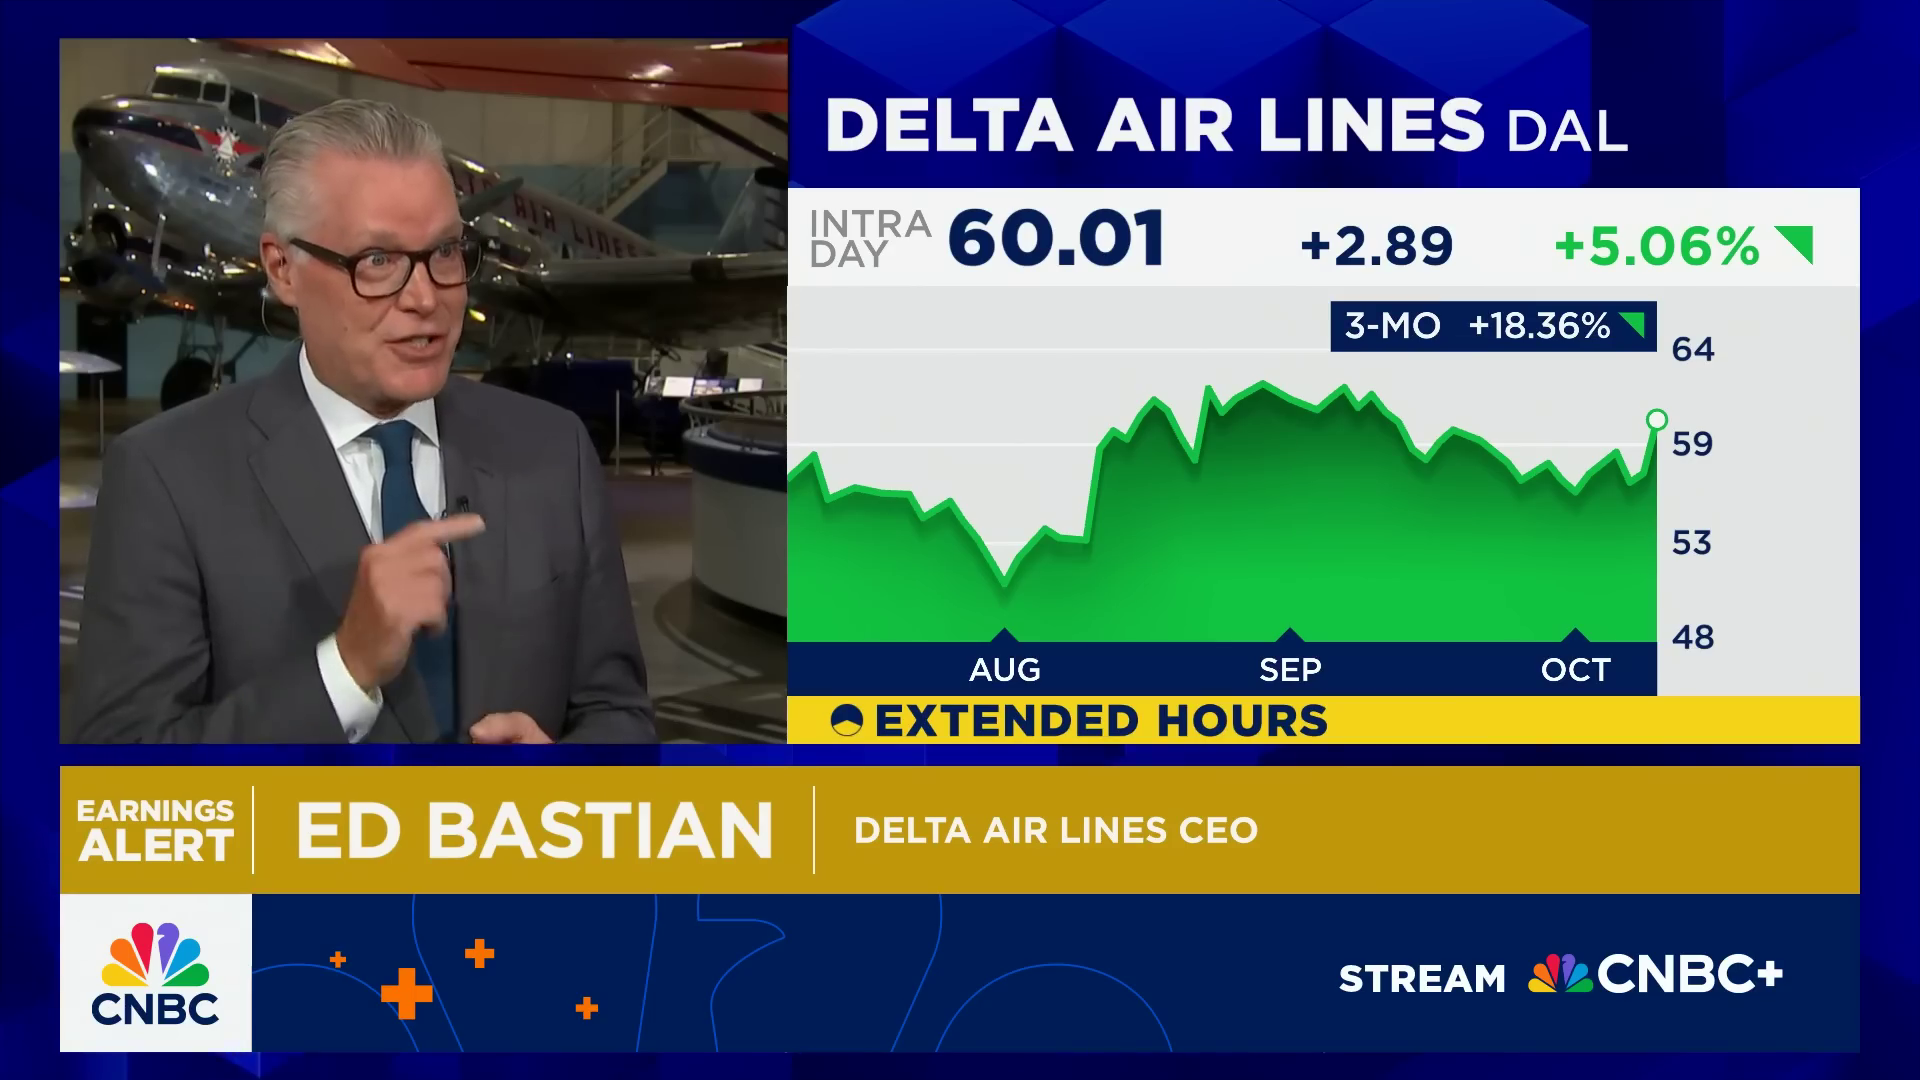

{'ts': 89.9899}

In [21]:
preview_count = min(4, len(frames))
for row in frames[:preview_count]:
    display(Image(filename=row['frame']))
    display({k: v for k, v in row.items() if k != 'frame'})


## Score frames with the VLM
Make sure the OpenRouter API key is available. You can stop the loop early by setting `MAX_SCORING_FRAMES` above.

In [22]:
from openrouter_vlm import score_frame, OPENROUTER_KEY

if not OPENROUTER_KEY:
    raise RuntimeError('OPENROUTER_API_KEY is missing – load it (e.g. via .env) before scoring frames.')

iter_frames = frames if MAX_SCORING_FRAMES is None else frames[:MAX_SCORING_FRAMES]
scored_rows = []
for idx, row in enumerate(iter_frames, start=1):
    payload = score_frame(row['frame'])
    scored_rows.append({**row, **payload})
    if idx % 10 == 0 or idx == len(iter_frames):
        print(f'Scored {idx}/{len(iter_frames)} frames')

vlm_df = pd.DataFrame(scored_rows)
vlm_df.head()

Scored 8/8 frames


,frame,ts,valence,arousal,intensity,confidence,notes
0,/home/guest/Desktop/wqmsc/Capstone_project/fac...,0.000000,-0.20,0.20,0.20,0.40,Neutral to mildly negative expression — lips p...
1,/home/guest/Desktop/wqmsc/Capstone_project/fac...,29.996633,0.15,0.75,0.60,0.60,Mid-speech frame with open mouth and widened e...
2,/home/guest/Desktop/wqmsc/Capstone_project/fac...,59.993267,-0.20,0.25,0.20,0.45,"neutral-to-serious expression; lips pressed, s..."
3,/home/guest/Desktop/wqmsc/Capstone_project/fac...,89.989900,0.25,0.65,0.55,0.45,"Assertive, engaged mid-speech; slight positive..."
4,/home/guest/Desktop/wqmsc/Capstone_project/fac...,119.986533,0.10,0.20,0.20,0.45,"Neutral, composed expression with slight posit..."


,ts,valence,arousal,intensity,confidence
count,8.000000,8.000000,8.000000,8.000000,8.000000
mean,104.988217,-0.031250,0.437500,0.356250,0.450000
std,73.476446,0.173076,0.206588,0.161328,0.065465
min,0.000000,-0.200000,0.200000,0.200000,0.400000
25%,52.494108,-0.162500,0.237500,0.200000,0.400000
50%,104.988217,-0.100000,0.475000,0.325000,0.450000
75%,157.482325,0.112500,0.537500,0.475000,0.450000
max,209.976433,0.250000,0.750000,0.600000,0.600000


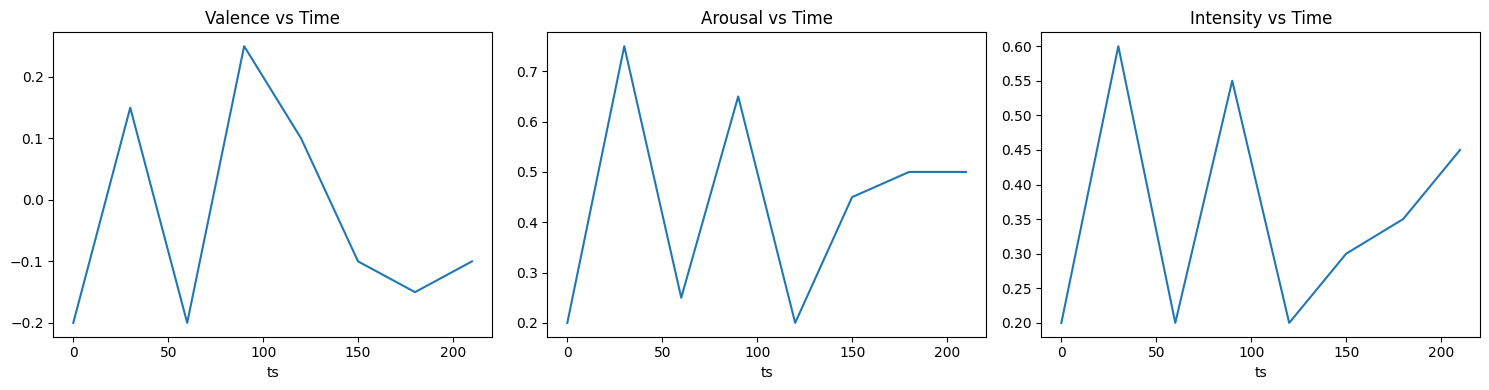

In [23]:
# Basic distribution plots
if 'vlm_df' in globals():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    vlm_df.plot(x='ts', y='valence', ax=axes[0], title='Valence vs Time', legend=False)
    vlm_df.plot(x='ts', y='arousal', ax=axes[1], title='Arousal vs Time', legend=False)
    vlm_df.plot(x='ts', y='intensity', ax=axes[2], title='Intensity vs Time', legend=False)
    plt.tight_layout()
    display(vlm_df.describe())
else:
    print('Run the scoring cell first.')

## Aggregate VLM features

In [24]:
from features_vlm import build_vlm_features

if 'scored_rows' not in globals() or not scored_rows:
    raise RuntimeError('No scored rows found – make sure the VLM scoring step ran successfully.')

feature_df = build_vlm_features(scored_rows, window_s=WINDOW, min_conf=MIN_CONF)
print(feature_df.shape)
feature_df

(1, 15)


,v_mean,v_std,a_mean,i_mean,i_max,n_frames,v_mean_lag1,a_mean_lag1,i_mean_lag1,v_mean_lag2,a_mean_lag2,i_mean_lag2,v_mean_lag3,a_mean_lag3,i_mean_lag3
0,0.15,0.0,0.75,0.6,0.6,1,0.15,0.75,0.6,0.15,0.75,0.6,0.15,0.75,0.6


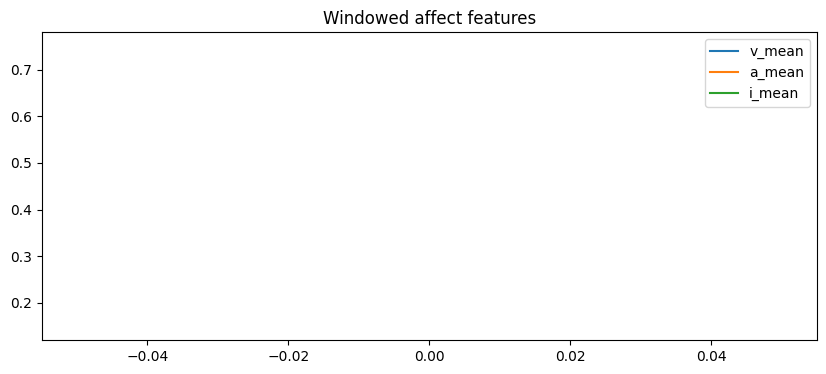

In [25]:
feature_df[['v_mean', 'a_mean', 'i_mean']].plot(kind='line', figsize=(10, 4), title='Windowed affect features')
plt.show()

## Price-aligned features and labels

In [26]:
from features_price import load_price_features

event_dt = datetime.fromisoformat(EVENT_TIME.replace('Z', '+00:00'))
px_features, labels = load_price_features(str(BARS_PATH), event_dt, HORIZONS)
print('Price features at event:')
display(px_features)
print('Future return labels:')
display(labels)

Price features at event:


{'px_close': np.float64(61.595001220703125),
 'px_ret_5m': np.float64(nan),
 'px_vol_norm': np.float64(1.0)}

Future return labels:


{}

## Combine everything and run the directional model

In [27]:
from train_eval import train_directional_model

combined_df = feature_df.assign(**px_features)
results = []
for horizon in HORIZONS:
    label_key = f'dir_{horizon}m'
    if label_key not in labels:
        results.append({'horizon_m': horizon, 'direction': 'n/a', 'prob_up': None, 'holdout_acc': None, 'note': 'Missing label'})
        continue
    label_series = pd.Series([labels[label_key]] * len(combined_df))
    model, score = train_directional_model(combined_df, label_series)
    if model is None:
        direction = '↑' if labels[label_key] else '↓'
        results.append({'horizon_m': horizon, 'direction': direction, 'prob_up': None, 'holdout_acc': None, 'note': 'Insufficient samples'})
        continue
    prob_up = model.predict_proba(combined_df.values)[-1, 1]
    direction = '↑' if prob_up >= 0.5 else '↓'
    results.append({'horizon_m': horizon, 'direction': direction, 'prob_up': round(prob_up, 3), 'holdout_acc': round(score, 3) if score is not None else None, 'note': ''})

pd.DataFrame(results)

,horizon_m,direction,prob_up,holdout_acc,note
0,5,n/a,None,None,Missing label
1,60,n/a,None,None,Missing label


## Save results (optional)

In [ ]:
# Uncomment to persist intermediate CSVs for further analysis
# Path('outputs').mkdir(exist_ok=True)
# vlm_df.to_csv('outputs/vlm_scores.csv', index=False)
# feature_df.to_csv('outputs/vlm_features.csv', index=False)

### Next steps
- Experiment with different frame strides or time windows.
- Try multiple videos by updating the configuration cell.
- Use the new Streamlit dashboard (`streamlit run vlm-demo/src/app.py`) for a GUI-driven experience.